# C13 · Scale-up from a partial screen: model the yields, then price the next experiment

| | |
|---|---|
| **Difficulty** | ★★★★☆ |
| **Time** | 4-5 hours |
| **Data** | Shields et al. (2021, *Nature* 590:89-96): a palladium-catalysed direct arylation run under **every** combination of 12 ligands x 4 bases x 4 solvents x 3 concentrations x 3 temperatures (1,728 yields). You get a random 60 of them; the rest is held back for auditing |
| **Skills** | Bounded outcomes with a pile of zeros (censoring on a transformed scale) · hierarchical ANOVA with shrunk two-way interactions (`ZeroSumNormal`) · a noise-vs-interaction ridge and checking it in function space · LOO · predicting a whole design space · P(best) and the posterior of the best achievable yield · scoring predictions against held-out truth (CRPS, coverage) · value of information for a batch of experiments · checking a decision rule on replayed screens |

## The brief

A process chemistry group has to fix the conditions for scaling up a C-H arylation. There are
**1,728** candidate conditions (ligand, base, solvent, concentration, temperature). Their
high-throughput robot ran a **seeded random 60** of them last month. The head of the group asks:

> "Our best screened condition gave about 91%. Do we lock it in for the pilot plant now, or do
> we buy another round of screening first? If another round, how many reactions? I want an
> expected value and the probability that it pays off - not a feeling."

The economics, agreed with finance:

* every percentage point of yield at scale is worth **$5,000** over the planned campaigns
  (assume screening yields carry over to the plant);
* one more screening reaction costs **$1,500** (materials, analysis, chemist time), and any
  extra round delays the pilot plant by a week, which costs **$10,000** whatever its size;
* only a condition that has actually been run can go to the plant: after an extra round they
  take the best *measured* condition (screen or new round). Treat recorded yields as exact - the
  table has no replicates.

Your job: build a model of yield over the whole grid from the 60 reactions, say which
conditions could be the best and how good the best could be, then turn that into the decision.
Because this dataset is a **complete** screen, you can then do what no real group can: audit
every prediction and every decision against the truth.

This is the sequel to example **E82** (Bayesian optimisation). E82 is about the sequential loop
(which experiment next, one at a time) and uses a Gaussian process on raw yields. Here the loop
is not the point: the questions are what the *model* of a partial screen should look like and
how to price the next batch. Do E82 first; its "Try it yourself" 1 and 2 are where this starts.

## How this notebook works

- Each task states **what to deliver**, not how. Write your code in the `YOUR CODE HERE` cells.
- Stuck? `h.hint("task3")` reveals hints one level at a time: *nudge → approach → code skeleton*.
  Try to get by on nudges.
- `h.check("task2", sigma=...)` compares your numbers with the reference solution.
- A full worked solution lives in `notebooks/solutions/`. Open it only when you are done (or truly stuck).

In [1]:
import logging
import time

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import xarray as xr
from scipy.special import expit, logit

from pymc_challenges import Hints, data

RANDOM_SEED = 2021
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # several fits: no sampler banner per fit
T_START = time.time()

h = Hints("C13")
h.tasks()

**C13 - Scale-up from a partial screen: model the yields, then price the next experiment**

- `task0` - Look at the screen (2 hints)
- `task1` - A Gaussian ANOVA on raw yield (3 hints, 3 check(s))
- `task2` - A likelihood that knows what a yield is (3 hints, 2 check(s))
- `task3` - Interactions from 60 reactions (3 hints, 2 check(s))
- `task4` - The whole grid (3 hints, 3 check(s))
- `task5` - Commit now, or buy k more reactions? (3 hints, 3 check(s))
- `task6` - Replay the decision (3 hints, 3 check(s))

## The data

The full table is loaded once and put in grid order (ligand x base x solvent x concentration x
temperature, as in E82), so row `i` of `IDX` gives the level indices of condition `i`. The
screen is the seeded random 60. `TRUTH` holds all 1,728 yields: **do not use it before Task 4**;
from then on it is your audit, never an input to a model or a decision.

In [2]:
data.describe("edbo_arylation")
grid = data.load("edbo_arylation")
FACT = ["ligand", "base", "solvent", "concentration", "temperature"]
LEV = [sorted(grid[f].unique()) for f in FACT]
NL = [len(lv) for lv in LEV]
for f, lv in zip(FACT, LEV):
    grid[f + "_i"] = pd.Index(lv).get_indexer(grid[f])
grid = grid.sort_values([f + "_i" for f in FACT]).reset_index(drop=True)
IDX = grid[[f + "_i" for f in FACT]].to_numpy()
N = len(grid)
assert N == np.prod(NL) and (np.ravel_multi_index(IDX.T, NL) == np.arange(N)).all()

SCREEN = np.sort(np.random.default_rng(13).choice(N, 60, replace=False))  # the robot's 60 runs
screen = grid.loc[SCREEN, FACT + ["yield"]]
TRUTH = grid["yield"].to_numpy()  # the audit: hands off until Task 4
CANDIDATES = np.setdiff1d(np.arange(N), SCREEN)  # the 1,668 conditions nobody has run
for f, lv in zip(FACT, LEV):
    print(f"{f:13s} {len(lv):2d} levels: {', '.join(map(str, lv))}")
screen.sort_values("yield", ascending=False).head(8)

edbo_arylation: A fully enumerated high-throughput screen of a palladium-catalysed direct (C-H) arylation: every combination of 12 phosphine ligands x 4 carboxylate bases x 4 solvents x 3 concentrations x 3 temperatures, one yield each (1,728 rows): ligand, base, solvent, concentration (M: 0.057, 0.1, 0.153), temperature (C: 90, 105, 120), yield (%, 0-100).
  source: Shields, Stevens, Li, Parasram, Damani, Martinez Alvarado, Janey, Adams & Doyle (2021), Bayesian reaction optimization as a tool for chemical synthesis, Nature 590:89-96; data from the authors' repository github.com/b-shields/edbo (MIT licence, (c) 2020 Benjamin J. Shields). BUILT by tools/build_e82_arylation.py (SMILES replaced by the names in the repository's *-list.csv files) - keep the cached file.
  url:    https://raw.githubusercontent.com/b-shields/edbo/master/experiments/data/direct_arylation/experiment_index.csv
ligand        12 levels: BrettPhos, CgMe-PPh, GorlosPhos HBF4, JackiePhos, P(fur)3, PCy3 HBF4, PPh2Me, 

,ligand,base,solvent,concentration,temperature,yield
202,CgMe-PPh,CsOPiv,DMAc,0.100,105,91.11
199,CgMe-PPh,CsOPiv,DMAc,0.057,105,91.06
1452,X-Phos,CsOAc,BuOAc,0.100,90,85.24
1444,X-Phos,CsOAc,BuCN,0.100,105,83.83
1678,tBPh-CPhos,KOAc,DMAc,0.100,105,78.95
1534,X-Phos,KOAc,DMAc,0.100,105,65.37
1525,X-Phos,KOAc,BuOAc,0.100,105,64.62
4,BrettPhos,CsOAc,BuCN,0.100,105,64.48


## Task 0 · Look at the screen

Only the 60 screened yields. **Deliver**
1. The distribution of the yields: how many are exactly 0, how many are traces (below 1%),
   how close does anything come to 100%?
2. How much of the design does the screen cover: reactions per ligand, and how many of the
   48 ligand x solvent and 48 ligand x base combinations were run at all?
3. One sentence: what does a likelihood for these numbers have to be able to do?

60 reactions: exactly 0 in 18, traces (0 < y < 1%) in 0, below 5% in 27, at or above 80% in 4; best 91.1%
reactions per ligand: {'BrettPhos': np.int64(5), 'CgMe-PPh': np.int64(4), 'GorlosPhos HBF4': np.int64(1), 'JackiePhos': np.int64(5), 'P(fur)3': np.int64(6), 'PCy3 HBF4': np.int64(3), 'PPh2Me': np.int64(3), 'PPh3': np.int64(4), 'PPhMe2': np.int64(3), 'PPhtBu2': np.int64(10), 'X-Phos': np.int64(8), 'tBPh-CPhos': np.int64(8)}
ligand x solvent: 36 of 48 combinations run at least once
ligand x base: 36 of 48 combinations run at least once
base x solvent: 15 of 16 combinations run at least once


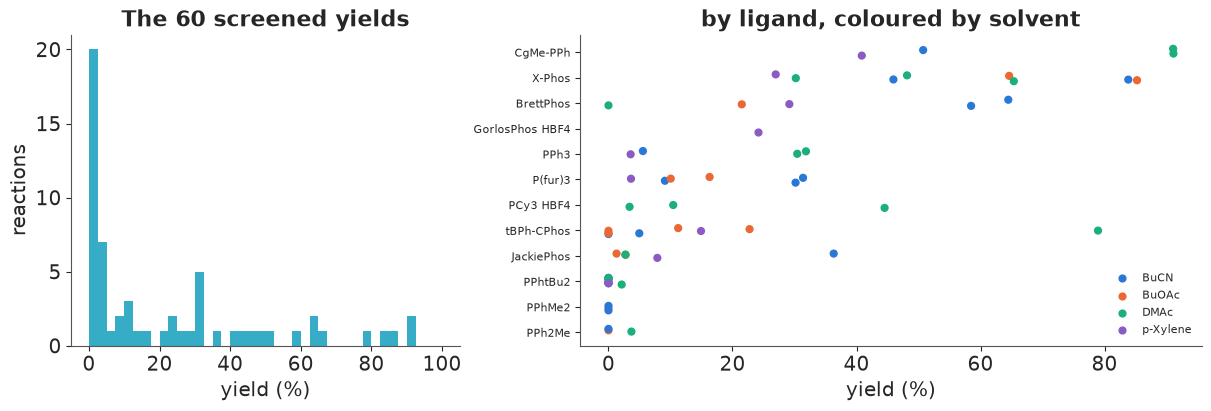

In [3]:
y = screen["yield"].to_numpy()
X = IDX[SCREEN]
print(f"{len(y)} reactions: exactly 0 in {np.sum(y == 0)}, traces (0 < y < 1%) in "
      f"{np.sum((y > 0) & (y < 1))}, below 5% in {np.sum(y < 5)}, at or above 80% in {np.sum(y >= 80)}; "
      f"best {y.max():.1f}%")
print("reactions per ligand:", dict(screen["ligand"].value_counts().sort_index()))
for p, q in [(0, 2), (0, 1), (1, 2)]:
    seen = len({(a, b) for a, b in X[:, [p, q]]})
    print(f"{FACT[p]} x {FACT[q]}: {seen} of {NL[p] * NL[q]} combinations run at least once")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), width_ratios=[1, 1.6])
axes[0].hist(y, bins=np.arange(0, 102.5, 2.5), color="C0")
axes[0].set(xlabel="yield (%)", ylabel="reactions", title="The 60 screened yields")
order = screen.groupby("ligand")["yield"].median().sort_values().index
SOLV_COL = dict(zip(LEV[2], ["#2a78d6", "#eb6834", "#1baf7a", "#8a5cc2"]))
for k, lig in enumerate(order):
    sub = screen[screen["ligand"] == lig]
    axes[1].scatter(sub["yield"], np.full(len(sub), k) + rng.uniform(-0.15, 0.15, len(sub)),
                    color=[SOLV_COL[v] for v in sub["solvent"]], s=24)
for v, c in SOLV_COL.items():
    axes[1].scatter([], [], color=c, s=24, label=v)
axes[1].set_yticks(range(len(order)), order, fontsize=8)
axes[1].set(xlabel="yield (%)", title="by ligand, coloured by solvent")
axes[1].legend(fontsize=8, loc="lower right");

### Solution

Nearly a third of the screen (18 of 60) gave **exactly 0**, nothing landed strictly between 0 and
1%, and 27 reactions gave under 5%. At the other end, four reached 80% and the best two are
91.1% and 91.06% - the same ligand, base and solvent (CgMe-PPh, CsOPiv, DMAc) at two
concentrations. Nothing reached 100%, but yields are capped there.

Coverage is thin: between 1 (GorlosPhos) and 10 (PPhtBu2) reactions per ligand, and 36 of the 48
ligand x solvent and 36 of the 48 ligand x base combinations were run at all - mostly once.
Ligands dominate the picture: three give nothing anywhere (PPh2Me, PPhMe2, PPhtBu2), CgMe-PPh and
X-Phos give the best results. The first hint of an interaction is **tBPh-CPhos**: 79% in DMAc,
at most 23% in the other solvents.

So a likelihood for these numbers must (i) never predict below 0 or above 100, (ii) put a real
lump of probability on "nothing happened", and (iii) let a factor's effect depend on whether the
reaction works at all - pushing 10% to 20% is not the same as pushing 90% to 100%.

## Task 1 · The default: a Gaussian ANOVA on raw yield

The model most people write first: yield (%) = intercept + one effect per level of each of the
five factors + Normal noise, with the effects of each factor shrunk towards zero by a shared
scale (a hierarchical ANOVA, E02).

**Deliver**
1. A fitted model with clean diagnostics.
2. A posterior predictive check aimed at the features you listed in Task 0.
3. Predictions for all 1,728 conditions (the "table" the model expects - latent mean plus
   noise): what share of them is negative, and what is the posterior of the **best achievable
   yield** (the largest predicted yield over the grid)? Would you show this to the head of the group?

### Solution

One builder serves every model in this notebook, so that later comparisons change one thing at a
time. Main effects are **non-centred** zero-sum effects (`s_f * ZeroSumNormal(1)`): with three
levels, a factor's scale is barely identified and the centred version funnels. Priors on the raw
scale: intercept Normal(30, 20), effect scales HalfNormal(20) - a factor can move yields by tens of
points - and noise HalfNormal(20).

In [4]:
COORDS = {f: [str(lv) for lv in levels] for f, levels in zip(FACT, LEV)}
PAIRS = [(0, 2), (0, 1), (1, 2)]  # ligand x solvent, ligand x base, base x solvent
Y_LO, Y_HI = 1.0, 99.5  # logit scale: below 1% is "trace", above 99.5% is "quantitative"
Z_LO, Z_HI = logit(Y_LO / 100), logit(Y_HI / 100)


def to_z(yv):
    return logit(np.clip(yv, Y_LO, Y_HI) / 100)


def anova_model(scale, pairs=(), centred=False, Xs=None, ys=None):
    """Hierarchical ANOVA of the screen.
    scale='raw':   yield (%) ~ Normal(mu, sigma)
    scale='logit': logit(yield) ~ Normal(mu, sigma), censored below 1% and above 99.5%."""
    Xs = X if Xs is None else Xs
    ys = y if ys is None else ys
    raw = scale == "raw"
    with pm.Model(coords=COORDS) as m:
        mu = pm.Normal("a", 30.0, 20.0) if raw else pm.Normal("a", -1.0, 1.5)
        for j, f in enumerate(FACT):
            s = pm.HalfNormal(f"s_{f}", 20.0 if raw else 1.5)
            e = pm.Deterministic(f"e_{f}", s * pm.ZeroSumNormal(f"z_{f}", sigma=1.0, dims=f), dims=f)
            mu = mu + e[Xs[:, j]]
        for p, q in pairs:
            name, dims = f"{FACT[p]}_x_{FACT[q]}", (FACT[p], FACT[q])
            s = pm.HalfNormal(f"s_{name}", 10.0 if raw else 1.0)
            if centred:
                e = pm.ZeroSumNormal(f"e_{name}", sigma=s, dims=dims, n_zerosum_axes=2)
            else:
                e = pm.Deterministic(f"e_{name}", s * pm.ZeroSumNormal(
                    f"z_{name}", sigma=1.0, dims=dims, n_zerosum_axes=2), dims=dims)
            mu = mu + e[Xs[:, p], Xs[:, q]]
        sigma = pm.HalfNormal("sigma", 20.0 if raw else 1.5)
        if raw:
            pm.Normal("y", mu, sigma, observed=ys)
        else:
            pm.Censored("y", pm.Normal.dist(mu, sigma), lower=Z_LO, upper=Z_HI, observed=to_z(ys))
    return m


def fit(model, seed=RANDOM_SEED, **kw):
    with model:
        idata = pm.sample(random_seed=seed, target_accept=0.95, progressbar=False, **kw)
    return idata


def diagnostics(idata, label):
    r = az.rhat(idata).to_dataset().to_dataarray().max().item()
    e = az.ess(idata).to_dataset().to_dataarray().min().item()
    print(f"{label}: divergences {int(idata.sample_stats['diverging'].sum())}, max r_hat {r:.3f}, "
          f"min bulk ESS {e:.0f}, tuning steps {idata.posterior.attrs.get('tuning_steps')}")


def grid_draws(idata, scale, pairs=(), n=2000, seed=RANDOM_SEED):
    """Posterior draws over all 1,728 conditions: latent mean `mu`, a latent draw `latent`
    (mean + noise) and the yield (%) the table would show. Shapes (n, 1728)."""
    post = az.extract(idata, num_samples=n, random_seed=seed)
    mu = post["a"].values[None, :] + 0.0
    for j, f in enumerate(FACT):
        mu = mu + post[f"e_{f}"].transpose(f, "sample").values[IDX[:, j]]
    for p, q in pairs:
        e = post[f"e_{FACT[p]}_x_{FACT[q]}"].transpose(FACT[p], FACT[q], "sample").values
        mu = mu + e[IDX[:, p], IDX[:, q]]
    mu = mu.T
    latent = mu + post["sigma"].values[:, None] * np.random.default_rng(seed).standard_normal(mu.shape)
    if scale == "raw":
        yld = latent
    else:  # read the latent draw the way the data were coded: < 1% -> 0, > 99.5% -> 100
        yld = 100 * expit(latent)
        yld = np.where(yld < Y_LO, 0.0, np.where(yld > Y_HI, 100.0, yld))
    return {"mu": mu, "latent": latent, "yield": yld}


naive = anova_model("raw")
idata_naive = fit(naive)
diagnostics(idata_naive, "Gaussian, raw yield")
az.summary(idata_naive, var_names=["a", "sigma"] + [f"s_{f}" for f in FACT], round_to=2)

Gaussian, raw yield: divergences 0, max r_hat 1.006, min bulk ESS 948, tuning steps 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a,21.55,2.69,17.23,25.90,3731.80,3198.08,1.00,0.04,0.04
sigma,17.51,1.95,14.66,20.93,2238.79,2452.40,1.00,0.04,0.03
s_ligand,20.46,5.11,13.35,29.52,1286.89,1818.34,1.00,0.14,0.10
s_base,8.26,6.32,0.96,19.59,1084.21,1023.09,1.00,0.16,0.14
s_solvent,7.82,6.11,0.78,19.26,1130.47,1103.39,1.01,0.15,0.13
s_concentration,9.79,7.77,1.08,24.42,948.04,927.39,1.00,0.21,0.15
s_temperature,6.87,6.48,0.54,19.46,1446.92,1874.96,1.00,0.15,0.15


              observed  replicated (median)  P(rep >= obs)
share <= 0       0.300                0.217          0.093
share < 1%       0.300                0.233          0.138
share >= 80%     0.067                0.017          0.090
max             91.110               89.035          0.430

predicted table: 22% of all yields negative; best achievable yield: median 113%, P(> 100%) = 0.91


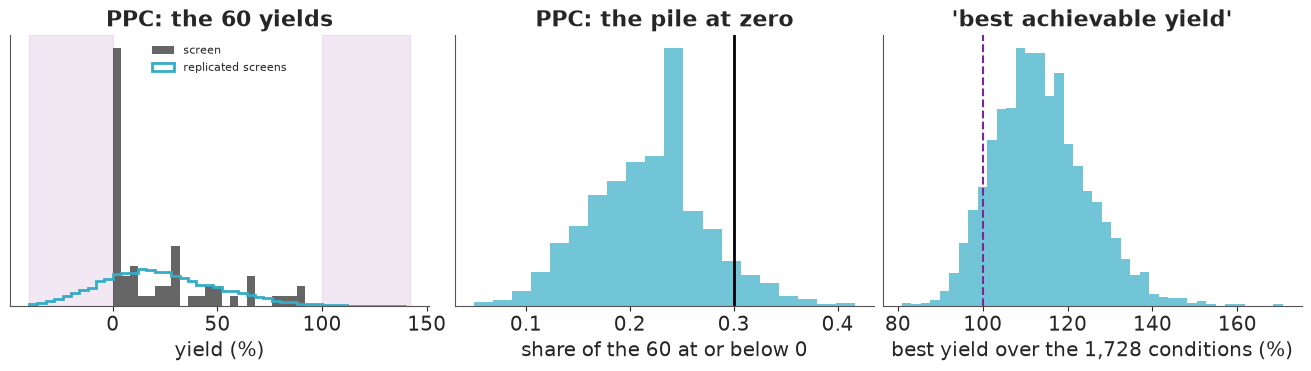

In [5]:
with naive:
    pm.sample_posterior_predictive(idata_naive, extend_inferencedata=True, random_seed=RANDOM_SEED,
                                   progressbar=False)
rep = az.extract(idata_naive, group="posterior_predictive", var_names=["y"]).values.T  # (draws, 60)
stats_obs = {"share <= 0": np.mean(y <= 0), "share < 1%": np.mean(y < 1), "share >= 80%": np.mean(y >= 80),
             "max": y.max()}
stats_rep = {"share <= 0": np.mean(rep <= 0, 1), "share < 1%": np.mean(rep < 1, 1),
             "share >= 80%": np.mean(rep >= 80, 1), "max": rep.max(1)}

G_naive = grid_draws(idata_naive, "raw")
share_negative = np.mean(G_naive["yield"] < 0)
best_naive = G_naive["yield"].max(1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].hist(y, bins=np.arange(-40, 142, 4), density=True, alpha=0.6, color="k", label="screen")
axes[0].hist(rep[:200].ravel(), bins=np.arange(-40, 142, 4), density=True, histtype="step", lw=2,
             color="C0", label="replicated screens")
axes[0].axvspan(-40, 0, color="C3", alpha=0.1)
axes[0].axvspan(100, 142, color="C3", alpha=0.1)
axes[0].set(xlabel="yield (%)", yticks=[], title="PPC: the 60 yields")
axes[0].legend(fontsize=8)
for ax, k in zip(axes[1:2], ["share <= 0"]):
    ax.hist(stats_rep[k], bins=20, color="C0", alpha=0.7)
    ax.axvline(stats_obs[k], color="k", lw=2)
    ax.set(xlabel="share of the 60 at or below 0", yticks=[], title="PPC: the pile at zero")
axes[2].hist(best_naive, bins=40, color="C0", alpha=0.7)
axes[2].axvline(100, color="C3", ls="--")
axes[2].set(xlabel="best yield over the 1,728 conditions (%)", yticks=[],
            title="'best achievable yield'");
print(pd.DataFrame({"observed": stats_obs,
                    "replicated (median)": {k: np.median(v) for k, v in stats_rep.items()},
                    "P(rep >= obs)": {k: np.mean(v >= stats_obs[k]) for k, v in stats_rep.items()}}).round(3))
print(f"\npredicted table: {share_negative:.0%} of all yields negative; best achievable yield: median "
      f"{np.median(best_naive):.0f}%, P(> 100%) = {np.mean(best_naive > 100):.2f}")

In [6]:
assert h.check("task1", sigma=idata_naive.posterior["sigma"].mean(), share_negative=share_negative,
               best_achievable=np.median(best_naive))

- PASS `sigma` = 17.51 is consistent with the reference solution.
- PASS `share_negative` = 0.2195 is consistent with the reference solution.
- PASS `best_achievable` = 112.9 is consistent with the reference solution.

The sampler is happy (no divergences, r_hat 1.01 at most) - and the model is still wrong in the
ways that matter here:

* **It predicts impossible yields.** About a fifth of the predicted table (22%) is negative, and
  the replicated screens spread smoothly through zero instead of piling up on it (left panel). The
  observed share at or below zero (30%) sits in the upper tail of the replicated shares (P = 0.09):
  the Gaussian makes "failures" by smearing probability below zero. It also makes too few good
  reactions: 7% of the screen is at 80% or more, 2% of a typical replicated screen (P = 0.09).
* **It promises the impossible at the top.** The posterior of the best achievable yield has its
  median at about 113%, and P(best > 100%) = 0.91 (right panel). Every number in the decision -
  how much better than 91% the best condition could be - comes from exactly this tail.

A 17-point noise sd is the price of one constant spread for reactions that fail (spread near 0)
and reactions that work (spread of tens of points). Nobody should see this "best achievable yield".

## Task 2 · A likelihood that knows what a yield is

**Deliver**
1. A likelihood that respects the bounds of a yield and produces a pile of zeros/traces and a
   ceiling naturally. Justify the scale on which factors act, and how you treat 0 and 100.
2. A prior predictive check on the yield scale: what share of reactions does your prior expect
   to fail, and what share to exceed 95%?
3. The fit, diagnostics, and the same posterior predictive check as in Task 1.

### Solution

Two choices, both about what a yield *is*:

* **Scale.** Model the latent log-odds of conversion, $\mathrm{logit}(y/100) = \mu + \varepsilon$,
  with $\mu$ the same ANOVA as before. On this scale an effect is a multiplier on the odds, so a
  good ligand can lift 10% to 40% without being able to lift 90% past 100%, and the noise is
  automatically small near both ends.
* **The ends.** A recorded 0 is not a measurement of $-\infty$ log-odds; it means "below what the
  assay sees". Everything below 1% is treated as **left-censored** at $\mathrm{logit}(0.01)$, and
  anything above 99.5% (none in this screen) as right-censored. `pm.Censored` turns those rows
  into $P(\text{latent} < \text{bound})$. (A Tobit model - censored Normal on the raw scale - also
  respects the bounds, but keeps one spread for 40% and 85% reactions; in development runs on eight
  random screens it scored worse against the held-out table in seven, and covered the truly good
  conditions much worse.)

Priors on the logit scale: intercept Normal(-1, 1.5) (a typical reaction near 25%, anything from
1% to 90% plausible), effect scales HalfNormal(1.5), noise HalfNormal(1.5). The prior predictive
check is on the yield scale.

In [7]:
additive = anova_model("logit")
with additive:
    prior = pm.sample_prior_predictive(500, random_seed=RANDOM_SEED)
prior_y = 100 * expit(az.extract(prior, group="prior_predictive", var_names=["y"]).values)  # (60, draws)
prior_trace = np.mean(prior_y < Y_LO + 1e-9, 0)  # censored draws sit exactly at the bound
prior_top = np.mean(prior_y > 95, 0)
print(f"prior predictive: share of traces/zeros per simulated screen, median {np.median(prior_trace):.2f} "
      f"(90%: {np.quantile(prior_trace, 0.05):.2f}-{np.quantile(prior_trace, 0.95):.2f}); "
      f"share above 95%: median {np.median(prior_top):.2f} "
      f"(90%: {np.quantile(prior_top, 0.05):.2f}-{np.quantile(prior_top, 0.95):.2f})")

idata_add = fit(additive)
diagnostics(idata_add, "censored logit, additive")
az.summary(idata_add, var_names=["a", "sigma"] + [f"s_{f}" for f in FACT], round_to=2)

prior predictive: share of traces/zeros per simulated screen, median 0.13 (90%: 0.00-0.42); share above 95%: median 0.10 (90%: 0.00-0.35)


censored logit, additive: divergences 0, max r_hat 1.005, min bulk ESS 1183, tuning steps 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a,-2.63,0.30,-3.12,-2.17,3245.59,2767.58,1.0,0.01,0.00
sigma,1.71,0.23,1.38,2.10,3162.18,2781.35,1.0,0.00,0.00
s_ligand,2.23,0.51,1.51,3.11,1556.39,2167.33,1.0,0.01,0.01
s_base,0.50,0.46,0.04,1.35,1462.61,1833.67,1.0,0.01,0.01
s_solvent,0.60,0.50,0.05,1.54,1183.23,1228.08,1.0,0.01,0.01
s_concentration,0.66,0.57,0.04,1.74,1307.24,1324.04,1.0,0.01,0.01
s_temperature,0.59,0.53,0.06,1.61,1671.28,1947.01,1.0,0.01,0.01


observed share below 1%: 0.30; replicated: median 0.27, P(rep >= obs) = 0.29
observed share >= 80%: 0.07; replicated: median 0.08
predicted table: best achievable yield median 100.0%, P(some condition >= 95%) = 1.00


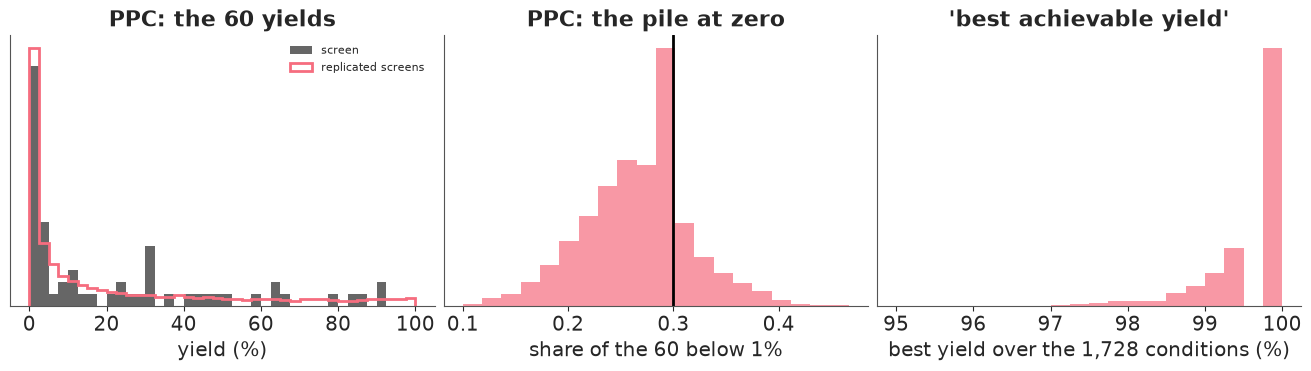

In [8]:
def ppc_logit(model, idata):
    with model:
        pm.sample_posterior_predictive(idata, extend_inferencedata=True, random_seed=RANDOM_SEED,
                                       progressbar=False)
    return 100 * expit(az.extract(idata, group="posterior_predictive", var_names=["y"]).values.T)


rep_add = ppc_logit(additive, idata_add)
G_add = grid_draws(idata_add, "logit")
share_trace = np.mean(rep_add < Y_LO + 1e-9)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].hist(y, bins=np.arange(0, 102.5, 2.5), density=True, alpha=0.6, color="k", label="screen")
axes[0].hist(rep_add[:200].ravel(), bins=np.arange(0, 102.5, 2.5), density=True, histtype="step", lw=2,
             color="C1", label="replicated screens")
axes[0].set(xlabel="yield (%)", yticks=[], title="PPC: the 60 yields")
axes[0].legend(fontsize=8)
axes[1].hist(np.mean(rep_add < Y_LO + 1e-9, 1), bins=20, color="C1", alpha=0.7)
axes[1].axvline(np.mean(y < Y_LO), color="k", lw=2)
axes[1].set(xlabel="share of the 60 below 1%", yticks=[], title="PPC: the pile at zero")
best_add = G_add["yield"].max(1)
axes[2].hist(best_add, bins=np.linspace(95, 100, 21), color="C1", alpha=0.7)
axes[2].set(xlabel="best yield over the 1,728 conditions (%)", yticks=[], title="'best achievable yield'");
print(f"observed share below 1%: {np.mean(y < Y_LO):.2f}; replicated: median "
      f"{np.median(np.mean(rep_add < Y_LO + 1e-9, 1)):.2f}, P(rep >= obs) = "
      f"{np.mean(np.mean(rep_add < Y_LO + 1e-9, 1) >= np.mean(y < Y_LO)):.2f}")
print(f"observed share >= 80%: {np.mean(y >= 80):.2f}; replicated: median "
      f"{np.median(np.mean(rep_add >= 80, 1)):.2f}")
print(f"predicted table: best achievable yield median {np.median(best_add):.1f}%, "
      f"P(some condition >= 95%) = {np.mean(best_add >= 95):.2f}")

In [9]:
assert h.check("task2", sigma=idata_add.posterior["sigma"].mean(), share_trace=share_trace)

- PASS `sigma` = 1.707 is consistent with the reference solution.
- PASS `share_trace` = 0.2649 is consistent with the reference solution.

The prior predictive is broad but sensible: the median simulated screen has about 13% failures
and 10% of reactions above 95%, and anything from none to about 40% of either is allowed - the
observed 30% failures and the 91% best are comfortably inside.

The fit is clean (no divergences, r_hat 1.005). The ligand dominates (scale about 2.2 logit units,
against about 0.5-0.7 for the other factors), and the residual sd is about 1.7 on the logit
scale. The posterior predictive check now has the pile: replicated screens have a median of 27%
of reactions below 1% against 30% observed (P = 0.29), and the share at or above 80% is matched
(8% vs 7%). The best achievable yield is now **bounded**: its posterior sits between 98% and
100%, with essentially every draw having some condition at 95% or more. That is a claim we can
check later (Task 4) - the full table has 10 such conditions.

## Task 3 · Interactions from 60 reactions

Chemists will tell you that a ligand can work in one solvent and fail in another. With 60
reactions spread over 48 ligand x solvent cells, most cells have been run once or never.

**Deliver**
1. Add **ligand x solvent**, **ligand x base** and **base x solvent** interactions to the model of
   Task 2, each shrunk towards zero by its own scale. Read the diagnostics carefully: something
   will be harder to sample than before. Find which parameters, explain why *in terms of the
   data*, and decide whether it matters for what the group needs - predictions of yields.
2. Posterior of the three interaction scales, and a LOO comparison with the additive model.
3. Which ligand x solvent combinations does the model think are special, and how sure is it?

### Solution

Interactions are `ZeroSumNormal` with `n_zerosum_axes=2` (each row and column sums to zero, so they
do not compete with the main effects and the intercept), scaled by a HalfNormal(1) on the logit
scale - an interaction of one logit unit turns 50% into 73%. They are non-centred, like the main
effects.

In [10]:
interact = anova_model("logit", PAIRS)
idata_int = fit(interact)
diagnostics(idata_int, "interactions, non-centred")
idata_centred = fit(anova_model("logit", PAIRS, centred=True))
diagnostics(idata_centred, "interactions, centred (for comparison)")
del idata_centred
print(az.summary(idata_int, var_names=["sigma", "s_ligand", "s_ligand_x_solvent", "s_ligand_x_base",
                                       "s_base_x_solvent"], round_to=2).to_string())
with additive:
    pm.compute_log_likelihood(idata_add, progressbar=False)
with interact:
    pm.compute_log_likelihood(idata_int, progressbar=False)
cmp = az.compare({"additive": idata_add, "interactions": idata_int}, round_to=1)
print(cmp)
elpd_diff = float(cmp.loc["interactions", "elpd"] - cmp.loc["additive", "elpd"])

interactions, non-centred: divergences 0, max r_hat 1.018, min bulk ESS 151, tuning steps 400


interactions, centred (for comparison): divergences 2, max r_hat 1.088, min bulk ESS 47, tuning steps 400
                    mean    sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  mcse_sd
sigma               1.09  0.37      0.49      1.72    150.83    249.32   1.02       0.03     0.01
s_ligand            2.29  0.52      1.55      3.20   1336.82   1543.65   1.00       0.01     0.01
s_ligand_x_solvent  1.05  0.48      0.17      1.76    216.45    297.66   1.01       0.03     0.01
s_ligand_x_base     0.76  0.41      0.13      1.43    361.72    599.99   1.02       0.02     0.01
s_base_x_solvent    0.79  0.46      0.11      1.55    754.25    635.47   1.00       0.01     0.01


              rank  elpd_diff  dse  p_worse diag_diff     diag_elpd     p  \
interactions     0        0.0  0.0      NaN            30 k̂ > 0.70  36.0   
additive         1       -9.7  2.4      1.0   N < 100   3 k̂ > 0.70  15.4   

               elpd   se  weight  
interactions  -92.1  6.6     1.0  
additive     -101.8  7.8     0.0  


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn

posterior correlation of sigma with s_ligand_x_solvent: -0.58, with s_ligand_x_base: -0.48
latent mean at the 50 most promising conditions: max r_hat 1.005, min bulk ESS 609


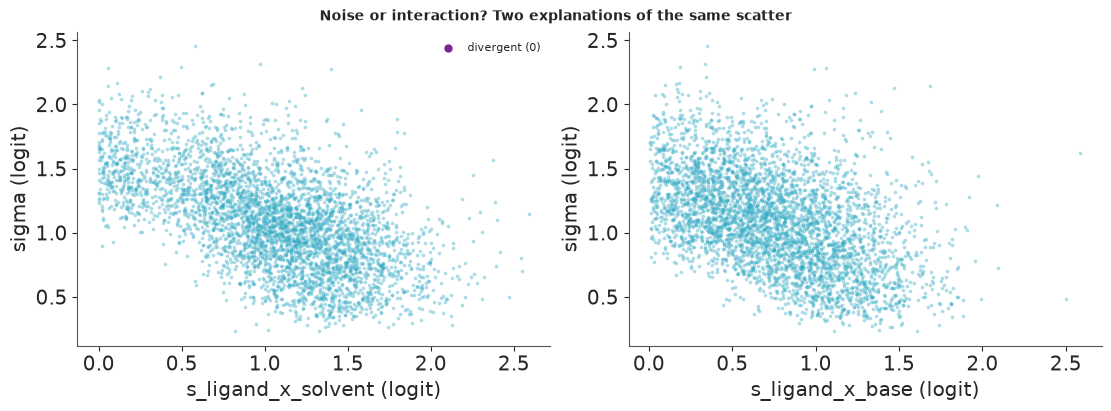

In [11]:
post_i = az.extract(idata_int, var_names=["sigma", "s_ligand_x_solvent", "s_ligand_x_base"])
div_i = idata_int.sample_stats["diverging"].values.ravel()
print(f"posterior correlation of sigma with s_ligand_x_solvent: "
      f"{np.corrcoef(post_i['sigma'], post_i['s_ligand_x_solvent'])[0, 1]:.2f}, with s_ligand_x_base: "
      f"{np.corrcoef(post_i['sigma'], post_i['s_ligand_x_base'])[0, 1]:.2f}")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, k in zip(axes, ["s_ligand_x_solvent", "s_ligand_x_base"]):
    ax.scatter(post_i[k], post_i["sigma"], s=3, alpha=0.3, color="C0")
    ax.scatter(post_i[k].values[div_i], post_i["sigma"].values[div_i], s=25, color="C3",
               label=f"divergent ({div_i.sum()})")
    ax.set(xlabel=k + " (logit)", ylabel="sigma (logit)")
axes[0].legend(fontsize=8)
fig.suptitle("Noise or interaction? Two explanations of the same scatter", fontsize=10)


def xr_idx(v):
    return xr.DataArray(v, dims="cond")


def mu_at(idata, cond, pairs=PAIRS):
    """Latent mean at chosen conditions, keeping (chain, draw) for r_hat / ESS."""
    po = idata.posterior
    out = po["a"] + 0.0
    for j, f in enumerate(FACT):
        out = out + po[f"e_{f}"].isel({f: xr_idx(IDX[cond, j])})
    for p, q in pairs:
        out = out + po[f"e_{FACT[p]}_x_{FACT[q]}"].isel({FACT[p]: xr_idx(IDX[cond, p]),
                                                         FACT[q]: xr_idx(IDX[cond, q])})
    return out


watch = np.argsort(grid_draws(idata_int, "logit", PAIRS)["mu"].mean(0))[-50:]  # 50 most promising
fs = xr.Dataset({"mu": mu_at(idata_int, watch)})
print(f"latent mean at the 50 most promising conditions: max r_hat {float(az.rhat(fs)['mu'].max()):.3f}, "
      f"min bulk ESS {float(az.ess(fs)['mu'].min()):.0f}")

BrettPhos    x DMAc    : mean -1.70, P(> 0) = 0.08, screened yields [0.0]
tBPh-CPhos   x DMAc    : mean +1.33, P(> 0) = 0.91, screened yields [79.0]
BrettPhos    x BuCN    : mean +1.03, P(> 0) = 0.90, screened yields [64.0, 58.0]
tBPh-CPhos   x BuOAc   : mean -0.82, P(> 0) = 0.13, screened yields [0.0, 0.0, 23.0, 11.0]
X-Phos       x BuOAc   : mean +0.58, P(> 0) = 0.82, screened yields [85.0, 65.0]


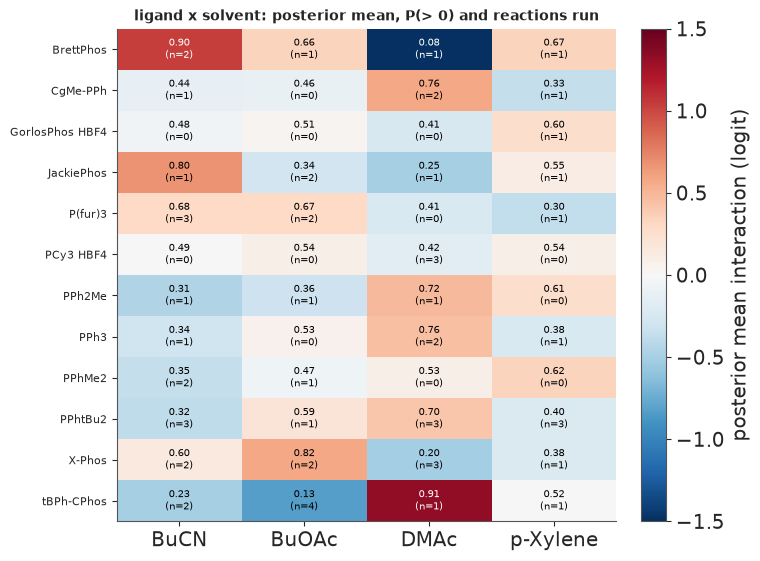

In [12]:
e_ls = idata_int.posterior["e_ligand_x_solvent"]
mean_ls = e_ls.mean(("chain", "draw")).values
p_pos = (e_ls > 0).mean(("chain", "draw")).values
n_ls = np.zeros((NL[0], NL[2]), int)
np.add.at(n_ls, (X[:, 0], X[:, 2]), 1)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
im = ax.imshow(mean_ls, cmap="RdBu_r", vmin=-1.5, vmax=1.5, aspect="auto")
for i in range(NL[0]):
    for j in range(NL[2]):
        ax.text(j, i, f"{p_pos[i, j]:.2f}\n(n={n_ls[i, j]})", ha="center", va="center", fontsize=7,
                color="w" if abs(mean_ls[i, j]) > 0.9 else "k")
ax.set_xticks(range(NL[2]), LEV[2])
ax.set_yticks(range(NL[0]), LEV[0], fontsize=8)
plt.colorbar(im, ax=ax, label="posterior mean interaction (logit)")
ax.set_title("ligand x solvent: posterior mean, P(> 0) and reactions run", fontsize=10)
sure = np.argsort(np.abs(p_pos - 0.5).ravel())[::-1][:5]
for i, j in zip(*np.unravel_index(sure, p_pos.shape)):
    sub = screen[(screen["ligand"] == LEV[0][i]) & (screen["solvent"] == LEV[2][j])]["yield"]
    print(f"{LEV[0][i]:12s} x {LEV[2][j]:8s}: mean {mean_ls[i, j]:+.2f}, P(> 0) = {p_pos[i, j]:.2f}, "
          f"screened yields {sub.round(0).tolist()}")

In [13]:
assert h.check("task3", s_ligand_solvent=idata_int.posterior["s_ligand_x_solvent"].mean(),
               elpd_diff=elpd_diff)

- PASS `s_ligand_solvent` = 1.049 is consistent with the reference solution.
- PASS `elpd_diff` = 9.7 is consistent with the reference solution.

**What the sampler says.** The non-centred model samples, but less comfortably than the additive one:
r_hat up to about 1.02 and a bulk ESS of about 150 for `sigma`, where the additive model had over
1,000. The centred version (for comparison) is worse - r_hat about 1.09 and ESS under 50 - so this is
not the usual funnel that non-centring cures. The scatter plots say what it is: `sigma` and the
interaction scales are **negatively correlated** (-0.6 and -0.5). With one reaction in most
ligand x solvent cells, "this cell is special" and "this reaction was noisy" are two explanations of
the same residual; the data fix their combined size, not the split. It is a property of the data,
not of the sampler, so the honest fix is to check that what we *use* is well determined: the latent
mean yield at the 50 most promising conditions has r_hat 1.005 and a bulk ESS above 600.
Predictions are fine; individual scales are uncertain, and we will not interpret them finely.

**What the interactions are.** The ligand x solvent scale is about 1 logit unit (89% interval
roughly 0.2-1.8), larger than the additive model's scales for base, solvent and the continuous
factors (0.5-0.7); the residual sd drops from about 1.7 to about 1.1. LOO prefers the interaction
model by about 10 nats
(standard error of the difference about 2.4) - but read the warnings: about half of the 60
observations have Pareto k above 0.7, because a reaction alone in its cell determines that cell's
effect, and leaving it out changes the posterior a lot. PSIS-LOO is unreliable here; exact K-fold
would be the fix. We have something better in this exercise - the held-out table (Task 4).

**Which cells are special.** The printed cells are the ones the model is surest about, and each is
backed by one to four reactions: tBPh-CPhos works in DMAc and nowhere else in the screen, BrettPhos
fails in DMAc but works in BuCN. Most cells sit at P(> 0) between 0.3 and 0.7 - the model knows it
does not know. Interactions shrunk this hard will *under*state the best combinations; keep that in
mind for the decision.

## Task 4 · The whole grid: which condition is best, and how good can it get?

**Deliver**, from your best model (and, for contrast, the Task 1 model):
1. For every one of the 1,728 conditions, the posterior probability that it is the best one
   (screened conditions keep their measured yield). The ten most likely, with their posterior
   yield. How concentrated is the probability?
2. The posterior of the **best achievable yield** and of the probability that some condition
   reaches 95%.
3. *Now* open the audit: score each model's predictions of the 1,668 unscreened yields against
   `TRUTH` (a proper scoring rule, interval coverage overall and among the truly good
   conditions), and say where the probability of being best actually went.

### Solution

A posterior draw of the latent surface plus noise is one plausible version of the full table.
Fix the screened conditions at their measured values, take the argmax in each draw, and count.
Ties matter: on the yield scale every draw above 99.5% would read 100, so the argmax is taken on
the latent (logit) scale. The best achievable yield is the maximum of each draw.

In [14]:
G_int = grid_draws(idata_int, "logit", PAIRS)


def p_best(G, scale):
    lat = G["latent"].copy()
    lat[:, SCREEN] = y if scale == "raw" else to_z(y) + 1e-6 * y  # measured; keep the order of ties
    return np.bincount(lat.argmax(1), minlength=N) / len(lat)


def best_achievable(G, scale):
    yy = G["yield"].copy()
    yy[:, SCREEN] = y
    return yy.max(1)


P_BEST = {"Gaussian, raw": p_best(G_naive, "raw"), "censored logit, additive": p_best(G_add, "logit"),
          "censored logit + interactions": p_best(G_int, "logit")}
BEST = {"Gaussian, raw": best_achievable(G_naive, "raw"),
        "censored logit, additive": best_achievable(G_add, "logit"),
        "censored logit + interactions": best_achievable(G_int, "logit")}
pb = P_BEST["censored logit + interactions"]
top = np.argsort(pb)[::-1][:10]
tab = grid.loc[top, FACT].assign(
    screened=np.isin(top, SCREEN), p_best=pb[top].round(3),
    post_mean_yield=np.mean(G_int["yield"][:, top], 0).round(1))
print(tab.to_string())
for k, v in BEST.items():
    print(f"{k:31s} best achievable: median {np.median(v):5.1f}%, 90% {np.quantile(v, 0.05):5.1f}-"
          f"{np.quantile(v, 0.95):5.1f}; P(some condition >= 95%) = {np.mean(v >= 95):.2f}; "
          f"top-10 conditions hold {np.sort(P_BEST[k])[-10:].sum():.2f} of P(best)")
p_best_top = pb.max()
p_reach_95 = np.mean(BEST["censored logit + interactions"] >= 95)

       ligand    base solvent  concentration  temperature  screened  p_best  post_mean_yield
167  CgMe-PPh   CsOAc    DMAc          0.100          120     False   0.024             75.8
238  CgMe-PPh    KOAc    DMAc          0.100          105     False   0.023             79.6
237  CgMe-PPh    KOAc    DMAc          0.100           90     False   0.022             77.6
166  CgMe-PPh   CsOAc    DMAc          0.100          105     False   0.020             77.1
239  CgMe-PPh    KOAc    DMAc          0.100          120     False   0.018             79.0
242  CgMe-PPh    KOAc    DMAc          0.153          120     False   0.018             75.9
170  CgMe-PPh   CsOAc    DMAc          0.153          120     False   0.016             71.9
235  CgMe-PPh    KOAc    DMAc          0.057          105     False   0.014             73.9
203  CgMe-PPh  CsOPiv    DMAc          0.100          120     False   0.012             81.1
265  CgMe-PPh   KOPiv   BuOAc          0.100          105     False   

**P(best) is diffuse.** The ten most likely winners are all CgMe-PPh, mostly in DMAc at 0.1 M with
KOAc or CsOAc, each with a probability of only 1-2.5%; together the top ten hold under a fifth of
the probability. That is the honest state of knowledge after 60 random reactions: the model knows
which *region* is good, not which condition is best. Their posterior mean yields (61-81%) are
below the 91% already measured - they are candidates because they are uncertain, not because
they are expected to win.

**Best achievable yield.** The Gaussian's median is about 113% (90% interval roughly 97-133%). Both
bounded models put it at 98-100%, with essentially every draw having some condition at 95% or more.

**The audit.** Everything below uses `TRUTH`. A proper score for a predictive distribution
against one number is the **CRPS** (in yield points; for a point forecast it reduces to the
absolute error), estimated from the draws as $E|Y - y| - \tfrac12 E|Y - Y'|$.

In [15]:
def crps(draws, obs):
    """Sample CRPS per column. draws (S, n), obs (n,)."""
    S = draws.shape[0]
    s = np.sort(draws, 0)
    w = (2 * np.arange(1, S + 1) - S - 1)[:, None]
    return np.abs(draws - obs).mean(0) - (w * s).sum(0) / S**2


hold = CANDIDATES
good = hold[TRUTH[hold] >= 80]
TRUTH_READ = np.where(TRUTH < Y_LO, 0.0, np.where(TRUTH > Y_HI, 100.0, TRUTH))  # coded like the model
rows = {}
for name, G in [("Gaussian, raw", G_naive), ("censored logit, additive", G_add),
                ("censored logit + interactions", G_int)]:
    yy = G["yield"][:, hold]
    lo, hi = np.quantile(yy, [0.05, 0.95], 0)
    inside = (TRUTH_READ[hold] >= lo) & (TRUTH_READ[hold] <= hi)
    rows[name] = {
        "CRPS (points)": crps(yy, TRUTH_READ[hold]).mean(),
        "RMSE of mean": np.sqrt(np.mean((yy.mean(0) - TRUTH_READ[hold]) ** 2)),
        "90% coverage": inside.mean(),
        "coverage, true < 1%": inside[TRUTH[hold] < Y_LO].mean(),
        "coverage, true >= 80%": inside[TRUTH[hold] >= 80].mean(),
        "above interval, true >= 80%": (TRUTH_READ[hold] > hi)[TRUTH[hold] >= 80].mean(),
        "P(best) on true >= 95%": P_BEST[name][TRUTH >= 95].sum(),  # uniform: 10 / 1728 = 0.006
        "true yield, top P(best)": TRUTH[np.argmax(P_BEST[name])],
    }
audit = pd.DataFrame(rows).T
print(f"{len(hold)} held-out conditions, {len(good)} of them truly >= 80%; {np.sum(TRUTH >= 95)} "
      f"conditions in the whole table reach 95% (best {TRUTH.max():.0f}%)")
print(audit.round(3).to_string())
crps_int = audit.loc["censored logit + interactions", "CRPS (points)"]

1668 held-out conditions, 63 of them truly >= 80%; 10 conditions in the whole table reach 95% (best 100%)
                               CRPS (points)  RMSE of mean  90% coverage  coverage, true < 1%  coverage, true >= 80%  above interval, true >= 80%  P(best) on true >= 95%  true yield, top P(best)
Gaussian, raw                         10.199        18.481         0.924                0.983                  0.587                        0.413                   0.072                    83.25
censored logit, additive               8.341        17.885         0.977                0.978                  0.698                        0.302                   0.059                    39.55
censored logit + interactions          7.917        17.502         0.973                0.989                  0.698                        0.302                   0.077                    81.63


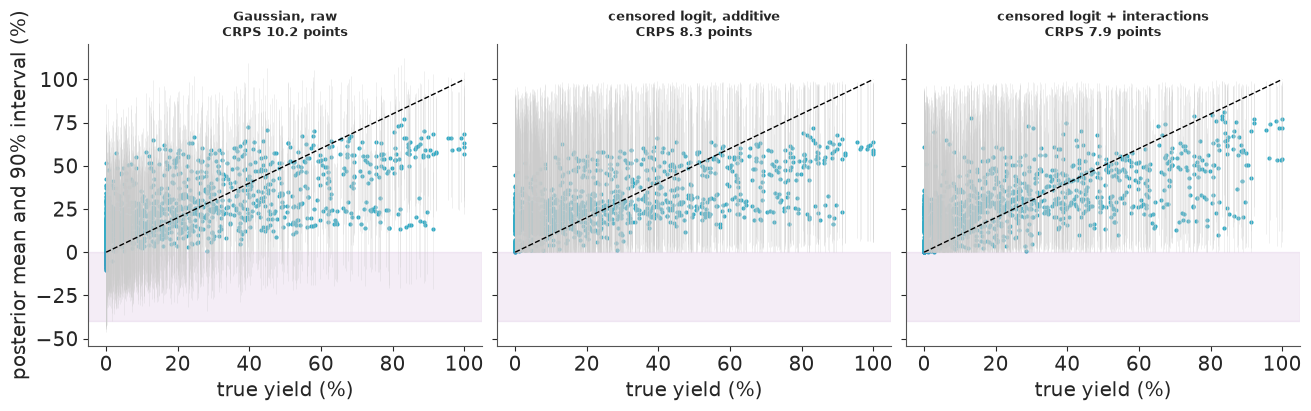

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, (name, G) in zip(axes, [("Gaussian, raw", G_naive), ("censored logit, additive", G_add),
                                ("censored logit + interactions", G_int)]):
    yy = G["yield"][:, hold]
    m, (lo, hi) = yy.mean(0), np.quantile(yy, [0.05, 0.95], 0)
    ax.errorbar(TRUTH[hold], m, yerr=[m - lo, hi - m], fmt="none", ecolor="0.8", lw=0.5, alpha=0.4)
    ax.scatter(TRUTH[hold], m, s=4, color="C0")
    ax.plot([0, 100], [0, 100], "k--", lw=1)
    ax.axhspan(-40, 0, color="C3", alpha=0.08)
    ax.set(xlabel="true yield (%)", title=f"{name}\nCRPS {rows[name]['CRPS (points)']:.1f} points")
    ax.title.set_fontsize(9)
axes[0].set_ylabel("posterior mean and 90% interval (%)");

In [17]:
assert h.check("task4", p_best_top=p_best_top, p_reach_95=p_reach_95, crps=crps_int)

- PASS `p_best_top` = 0.0245 is consistent with the reference solution.
- PASS `p_reach_95` = 0.998 is consistent with the reference solution.
- PASS `crps` = 7.917 is consistent with the reference solution.

What the audit says (1,668 unscreened conditions):

* **Proper score.** CRPS falls from 10.2 points (Gaussian) to 8.3 (bounded, additive) to 7.9 (bounded
  + interactions). The posterior *means* hardly differ (RMSE 17.5-18.5 points: 60 random reactions
  cannot predict individual yields well, scatter plots above); the gain is in the shape of the
  predictive distribution - a lump at zero and a ceiling.
* **Coverage.** Overall the bounded models' 90% intervals are too wide (97-98% coverage) and the
  failures are covered (98-99% of the truly < 1% reactions). But among the 63 conditions that truly
  give 80% or more, the intervals cover only 70% and the truth lies **above** the interval for the
  other 30% (Gaussian: 59% and 41%). Every model is too pessimistic about the best conditions -
  shrinkage of the effects that make them good, estimated from one or two reactions each.
* **Where P(best) went.** The ten conditions that truly reach 95% hold 7-8% of the probability under
  the interaction model, about 13 times their share under a uniform guess (0.6%). Its single most
  likely winner truly gives about 82%; the additive model's top pick gives 40% - without the
  ligand x solvent interaction it could not tell where CgMe-PPh works.

## Task 5 · Commit now, or buy k more reactions?

**Deliver**
1. For k = 0, 4, 8, 12, 16, 24, 32, 48 extra reactions: which k conditions you would run (your
   rule, from the posterior), the posterior distribution of the gain in yield over the current
   best measured condition, the expected **net value** in dollars (brief's economics), and the
   probability that it pays (net value > 0).
2. The same table from the Task 1 model. Do the two models recommend the same thing?
3. A recommendation to the head of the group in three sentences.
4. Then, using `TRUTH`: what would each recommendation actually have earned?

### Solution

After a round of $k$ reactions the group takes the best measured condition, so the gain is
$g_k = \max(0,\ \max_{j \in \text{batch}} y_j - y_\text{best})$ with $y_\text{best} = 91.1\%$, and the
net value is $5000\,g_k - 1500\,k - 10000\cdot 1[k > 0]$. Both depend on the *joint* posterior of the
batch's yields, which the grid draws give directly.

Which $k$ reactions? The batch whose best member is expected to beat the incumbent by the most
(a Monte-Carlo **q-EI**). Optimising it exactly is combinatorial; the greedy version adds, one at a
time, the condition that most increases $E[\max(y_\text{best}, \max_\text{batch} y)]$ over the draws.
A nested batch also makes the k's comparable.

In [18]:
VALUE_PER_POINT, COST_PER_RUN, COST_PER_ROUND = 5000, 1500, 10000
KS = [0, 4, 8, 12, 16, 24, 32, 48]
INCUMBENT = y.max()


def greedy_batch(yld, kmax, inc=INCUMBENT, cand=CANDIDATES):
    """Greedy Monte-Carlo q-EI: nested batches of 1..kmax unscreened conditions."""
    cur = np.full(yld.shape[0], inc)
    pool, batch = list(cand), []
    for _ in range(kmax):
        gain = np.maximum(yld[:, pool], cur[:, None]).mean(0)
        c = pool.pop(int(np.argmax(gain)))
        batch.append(c)
        cur = np.maximum(cur, yld[:, c])
    return np.array(batch)


def value_table(yld, batch, inc=INCUMBENT):
    out = {}
    for k in KS:
        g = np.zeros(len(yld)) if k == 0 else np.maximum(yld[:, batch[:k]].max(1) - inc, 0)
        net = VALUE_PER_POINT * g - COST_PER_RUN * k - COST_PER_ROUND * (k > 0)
        out[k] = {"E[gain] (points)": g.mean(), "P(gain > 0)": np.mean(g > 0),
                  "E[net] ($k)": net.mean() / 1000, "net 5% ($k)": np.quantile(net, 0.05) / 1000,
                  "net 95% ($k)": np.quantile(net, 0.95) / 1000, "P(pays)": np.mean(net > 0) if k else np.nan}
    return pd.DataFrame(out).T


def realised(batch, k, inc=INCUMBENT):
    if k == 0:
        return 0.0, 0.0
    g = max(0.0, TRUTH[batch[:k]].max() - inc)
    return g, (VALUE_PER_POINT * g - COST_PER_RUN * k - COST_PER_ROUND) / 1000


batch_int = greedy_batch(G_int["yield"], max(KS))
batch_naive = greedy_batch(G_naive["yield"], max(KS))
vt_int, vt_naive = value_table(G_int["yield"], batch_int), value_table(G_naive["yield"], batch_naive)
best_k_int, best_k_naive = int(vt_int["E[net] ($k)"].idxmax()), int(vt_naive["E[net] ($k)"].idxmax())
print("censored logit + interactions\n", vt_int.round(2).to_string())
print("\nGaussian, raw yield\n", vt_naive.round(2).to_string())
print(f"\nrecommended k: {best_k_int} (censored logit + interactions), {best_k_naive} (Gaussian)")
print("\nfirst 8 reactions of the batch (censored logit + interactions):")
print(grid.loc[batch_int[:8], FACT].assign(
    post_mean=np.mean(G_int["yield"][:, batch_int[:8]], 0).round(1),
    p_beats_incumbent=np.mean(G_int["yield"][:, batch_int[:8]] > INCUMBENT, 0).round(2)).to_string())

censored logit + interactions
     E[gain] (points)  P(gain > 0)  E[net] ($k)  net 5% ($k)  net 95% ($k)  P(pays)
0               0.00         0.00         0.00         0.00          0.00      NaN
4               4.69         0.80         7.46       -16.00         28.45     0.67
8               5.81         0.91         7.05       -22.00         22.45     0.75
12              6.39         0.96         3.95       -24.46         16.45     0.72
16              6.74         0.98        -0.31       -23.46         10.45     0.61
24              7.14         0.99       -10.29       -28.71         -1.55     0.00
32              7.38         0.99       -21.12       -36.17        -13.55     0.00
48              7.64         1.00       -43.81       -57.27        -37.55     0.00

Gaussian, raw yield
     E[gain] (points)  P(gain > 0)  E[net] ($k)  net 5% ($k)  net 95% ($k)  P(pays)
0               0.00         0.00         0.00          0.0          0.00      NaN
4               7.28         0.52 

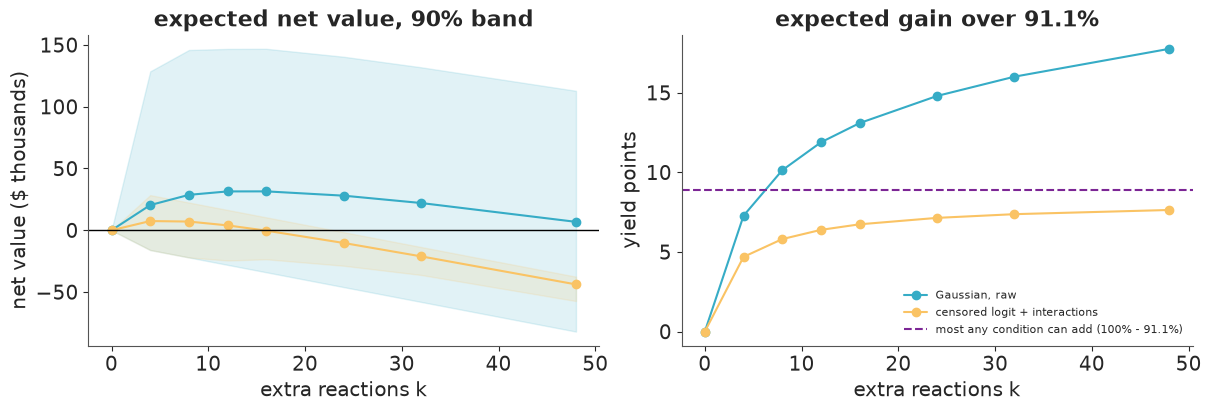

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for vt, name, c in [(vt_naive, "Gaussian, raw", "C0"), (vt_int, "censored logit + interactions", "C2")]:
    axes[0].plot(KS, vt["E[net] ($k)"], "o-", color=c, label=name)
    axes[0].fill_between(KS, vt["net 5% ($k)"], vt["net 95% ($k)"], color=c, alpha=0.15)
    axes[1].plot(KS, vt["E[gain] (points)"], "o-", color=c, label=name)
axes[0].axhline(0, color="k", lw=1)
axes[0].set(xlabel="extra reactions k", ylabel="net value ($ thousands)",
            title="expected net value, 90% band")
axes[1].axhline(100 - INCUMBENT, color="C3", ls="--", label="most any condition can add (100% - 91.1%)")
axes[1].set(xlabel="extra reactions k", ylabel="yield points", title="expected gain over 91.1%")
axes[1].legend(fontsize=8);

In [20]:
real = pd.DataFrame({name: {k: realised(b, k)[1] for k in KS}
                     for name, b in [("Gaussian, raw", batch_naive),
                                     ("censored logit + interactions", batch_int)]})
print("realised net value ($ thousands) of each k, with each model's batch, scored on TRUTH:")
print(real.round(1).T.to_string())
print(f"true best of the first {best_k_int} reactions of the logit batch: "
      f"{TRUTH[batch_int[:max(best_k_int, 1)]].max():.1f}%")
expected_gain_8 = vt_int.loc[8, "E[gain] (points)"]
p_pays = vt_int.loc[best_k_int, "P(pays)"] if best_k_int else vt_int.loc[8, "P(pays)"]

realised net value ($ thousands) of each k, with each model's batch, scored on TRUTH:
                                0     4     8     12    16   24    32    48
Gaussian, raw                  0.0 -16.0 -22.0  16.4  10.4 -1.6 -13.6 -37.6
censored logit + interactions  0.0 -16.0 -22.0 -22.6  10.4 -1.6 -13.6 -37.6
true best of the first 4 reactions of the logit batch: 83.8%


In [21]:
assert h.check("task5", expected_gain_8=expected_gain_8, best_k=best_k_int, p_pays=p_pays)

- PASS `expected_gain_8` = 5.81 is consistent with the reference solution.
- PASS `best_k` = 4 is consistent with the reference solution.
- PASS `p_pays` = 0.672 is consistent with the reference solution.

**The two models disagree, and the reason is visible in the right panel.** The Gaussian expects 10
points of gain from 8 reactions and 18 from 48 - more than the 8.9 points that separate 91.1% from
100%. Its 90% band for the net value reaches +$147k, a gain no condition can deliver. It recommends 16
reactions for an expected +$31k. The bounded interaction model knows the ceiling: its expected gain
flattens at 7-8 points, and the net value peaks at **4-8 reactions** (about +$7k either way, P(pays)
about 0.7), falls to zero by 16 and is negative with certainty from 24 on.

The batch it builds is concentrated: CgMe-PPh in DMAc at 0.1 M with three different bases, each with
a posterior mean of 76-81% and about a 40% chance of beating 91.1%. Four near-identical lottery
tickets look independent to the model (its noise is independent across conditions); in the real
table neighbouring conditions are correlated, so the batch is worth less than the model thinks
(Going further).

**Recommendation to the head of the group.** One small round is worth buying, but only just: four to
eight reactions around CgMe-PPh in DMAc have an expected value of about $7k and a 70% chance of
paying for themselves; any round larger than about 12 reactions loses money in expectation. If the
round does not beat 91% (a 1-in-5 chance by the model's account at k = 4), lock in today's best -
do not let the Gaussian's "16 more reactions, +$31k" argue for more.

**The audit.** On this screen the small round did *not* pay: the best of the first four reactions
truly gives 83.8%, so k = 4 loses $16k (and k = 8 loses $22k). The Gaussian's 16 reactions happen to
include a reaction at essentially 100% and earn +$10k - for the wrong reasons, since it expected
three times that.
One screen is one draw from the posterior's own uncertainty; Task 6 asks whether the rules are good.

## Task 6 · One screen is one anecdote: replay the decision

A single realised outcome cannot tell you whether a decision rule is good. Because you have the
full table, you can rerun the group's situation on other random screens of 60.

**Deliver** for at least six other screens, with both the Task 1 model and your best model:
the recommended k, the expected net value, and the realised net value against `TRUTH`. Then
a calibration check: where does the realised gain fall in each model's predictive distribution
of the gain (a PIT value)? Is either model systematically over- or under-optimistic?

### Solution

The whole pipeline - fit, grid draws, greedy batch, value table, recommended k - for six other
seeded screens. The PIT of the realised gain uses the recommended k (k = 8 when the
recommendation is 0, so that every screen contributes); ties at a gain of 0 get the mid-rank.

In [22]:
def pipeline(seed):
    scr = np.sort(np.random.default_rng(seed).choice(N, 60, replace=False))
    ys, Xs = TRUTH[scr], IDX[scr]
    cand, inc = np.setdiff1d(np.arange(N), scr), ys.max()
    out = {}
    for name, scale, pairs in [("Gaussian", "raw", ()), ("logit + interactions", "logit", PAIRS)]:
        idata = fit(anova_model(scale, pairs, Xs=Xs, ys=ys), seed=seed)
        nd = int(idata.sample_stats["diverging"].sum())
        yld = grid_draws(idata, scale, pairs, seed=seed)["yield"]
        del idata
        batch = greedy_batch(yld, max(KS), inc, cand)
        vt = value_table(yld, batch, inc)
        k = int(vt["E[net] ($k)"].idxmax())
        kp = k if k else 8
        g = np.maximum(yld[:, batch[:kp]].max(1) - inc, 0)
        g_true = realised(batch, kp, inc)[0]
        pit = np.mean(g < g_true) + 0.5 * np.mean(g == g_true)
        out[name] = {"incumbent": inc, "k": k, "E[net] ($k)": vt.loc[k, "E[net] ($k)"],
                     "realised ($k)": realised(batch, k, inc)[1], "E[gain] at k'": g.mean(),
                     "true gain at k'": g_true, "PIT": pit, "divergences": nd}
    return out


tic = time.time()
REPLAYS = {s: pipeline(s) for s in range(1, 7)}
replay = pd.concat({s: pd.DataFrame(v).T for s, v in REPLAYS.items()}, names=["screen seed", "model"])
print(f"{len(REPLAYS)} screens x 2 models in {time.time() - tic:.0f} s")
print(replay.astype(float).round(2).to_string())
summ = replay.astype(float).groupby(level="model")[["E[net] ($k)", "realised ($k)", "PIT"]].mean()
print("\nmeans over screens:\n", summ.round(2).to_string())

6 screens x 2 models in 47 s
                                  incumbent     k  E[net] ($k)  realised ($k)  E[gain] at k'  true gain at k'   PIT  divergences
screen seed model                                                                                                               
1           Gaussian                  98.49  16.0        45.89         -34.00          15.98             0.00  0.07          0.0
            logit + interactions      98.49   0.0         0.00           0.00           0.86             1.32  0.60          0.0
2           Gaussian                  88.89  12.0        14.42          27.55           8.48            11.11  0.68          0.0
            logit + interactions      88.89   8.0        13.07          26.00           7.01             9.60  0.64          0.0
3           Gaussian                  86.46  16.0        41.44         -24.25          15.09             1.95  0.21          0.0
            logit + interactions      86.46   4.0        31.94      

In [23]:
assert h.check("task6", mean_pit_logit=summ.loc["logit + interactions", "PIT"],
               realised_naive=summ.loc["Gaussian", "realised ($k)"],
               realised_logit=summ.loc["logit + interactions", "realised ($k)"])

- PASS `mean_pit_logit` = 0.807 is consistent with the reference solution.
- PASS `realised_naive` = 16.2 is consistent with the reference solution.
- PASS `realised_logit` = 45.38 is consistent with the reference solution.

Over six replayed screens:

* **The Gaussian's ceiling blindness costs real money.** On screen 1 the incumbent is already 98.5%;
  the Gaussian still recommends 16 more reactions (expected +$46k) and loses $34k. It lost money on
  three of the six screens and its recommendations realised about $16k on average against an
  expected $23k.
* **The bounded interaction model never lost money on these six**, declining to screen when the
  incumbent was 96.5% or more and buying 4-12 reactions otherwise; it realised about $45k on
  average against an expected $31k.
* **It is conservative.** Its PIT values are mostly high (0.6-0.97, mean about 0.8): the realised
  gains usually sat in the upper part of its predictive distribution. That is the same finding as the
  coverage audit in Task 4 - the best conditions are better than a shrunk 60-reaction model believes -
  so its recommended rounds are, if anything, too small. The Gaussian's mean PIT of 0.5 looks calibrated
  but hides errors in both directions (0.07 on screen 1, 0.98 on screen 5).

(One of the twelve replay fits had a few divergences - screen 3, interaction model; its numbers agree
with the others' pattern, but a careful analysis would refit it with a higher `target_accept`.)

Six screens (plus the main one, where the bounded model's round lost $16k) are a small sample, and they
share one table, so treat these as an illustration, not a benchmark. The lesson that survives: a
value-of-information calculation inherits every flaw of the model's tails, and a model that does not
know where yields end will always find the next round worth buying.

In [24]:
print(f"total run time {time.time() - T_START:.0f} s")

total run time 74 s


## Going further

- **Correlated residuals.** The interaction model's noise is independent across conditions, so a
  batch of near-identical conditions looks like several independent lottery tickets. Add a
  ligand x base x solvent effect (or a GP over concentration and temperature within each cell, E82)
  and see whether the batch spreads out and the value of a round changes.
- **Batches that learn.** The greedy batch ignores that running a reaction also *teaches* the
  model about its neighbours. Compare it with two rounds of half the size, refitting in between
  (a two-stage decision; E82's loop is the limit).
- **The chemists' game.** `edbo_arylation_game` holds 50 chemists' choices on the same table. Give
  each chemist's first 60 reactions to the model as the screen: is a chemist's (non-random) screen
  worth more or less to the model than a random one, and does the decision change?
- **Noisy yields.** Add replicate noise (say sd 5 points) to the screen and to the extra round, and
  let the group re-run the apparent winner before committing (E82 part H). What is a replicate worth?

In [25]:
h.progress()

**C13**: 0/20 hints used, 16/16 checks passed.